In [1]:
import sklearn
print(sklearn.__version__) 


1.7.1


In [2]:
pip install matplotlib pandas numpy scikit-learn joblib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
 #Import Libraries & Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Show first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#Check Data Info & Missing Values
# Dataset info
print(df.info())

# Missing values count
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
#Handle Missing & Incorrect Data
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15180\648362875.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [25]:
#Drop Irrelevant Columns
# customerID is not useful for prediction
df.drop('customerID', axis=1, inplace=True, errors='ignore')

In [26]:
#Encode Categorical Variables
# One-hot encode categorical features
df = pd.get_dummies(df, drop_first=True)

# Show first few rows after encoding
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,CustomerSegment
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,True,False,True,False,False,2
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,0
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,True,False,False,True,True,0
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,2
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,0


In [ ]:
# Save Clean Data for Later
df.to_csv("clean_telco.csv", index=False)
print("Clean dataset saved as clean_telco.csv")


In [ ]:
#Exploratory Data Analysis code

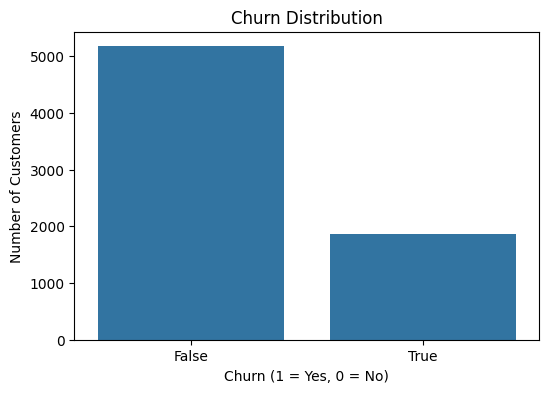

Churn Rate: 26.54%


In [11]:
#Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn_Yes', data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (1 = Yes, 0 = No)")
plt.ylabel("Number of Customers")
plt.show()

# Calculate churn percentage
churn_rate = df['Churn_Yes'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")


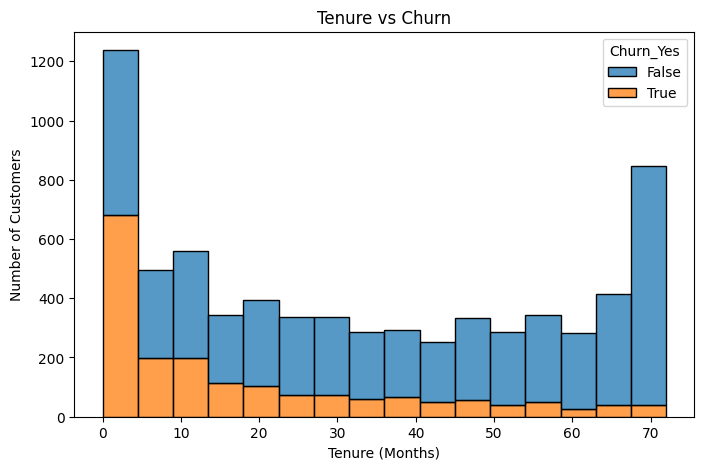

In [12]:
# Tenure vs Churn
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn_Yes', multiple='stack')
plt.title("Tenure vs Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()


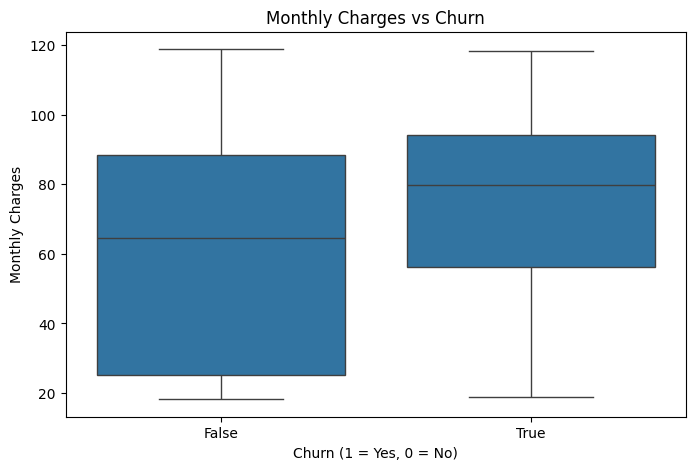

In [13]:
#Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn_Yes', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn (1 = Yes, 0 = No)")
plt.ylabel("Monthly Charges")
plt.show()


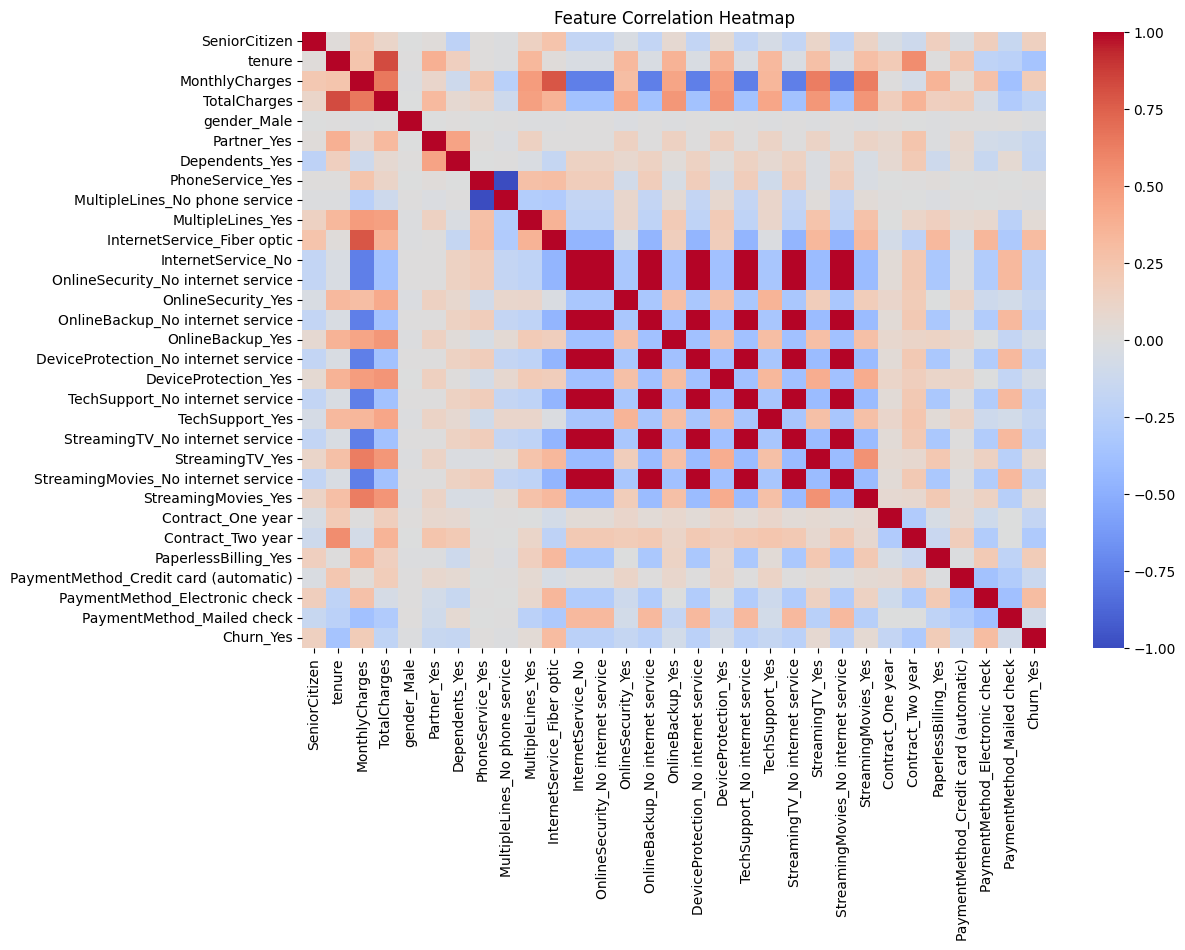

In [14]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


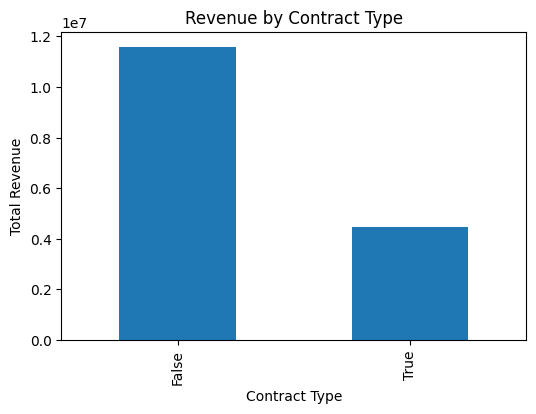

In [21]:
#Revenue Analysis using TotalCharges

plt.figure(figsize=(6,4))

revenue_contract = df.groupby('Contract_One year')['TotalCharges'].sum()

revenue_contract.plot(kind='bar')

plt.title("Revenue by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Total Revenue")

plt.show()

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for segmentation
seg_data = df[['tenure','MonthlyCharges','TotalCharges']]

# Scale the data
scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_data)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(seg_scaled)

# Add cluster column to dataset
df['CustomerSegment'] = clusters

print("Customer segmentation completed")

Customer segmentation completed


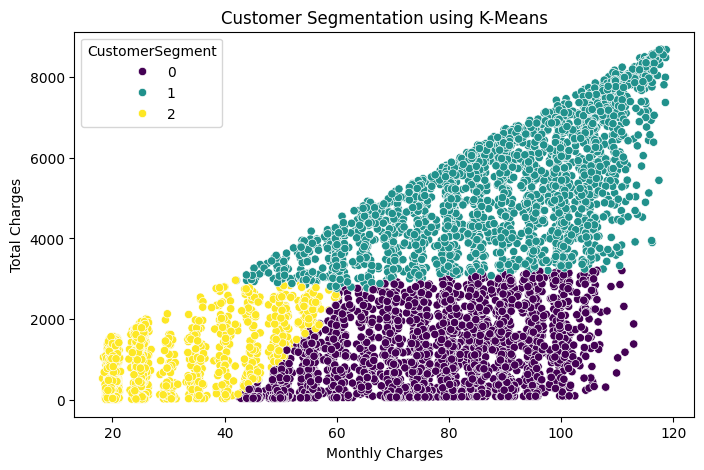

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['MonthlyCharges'],
    y=df['TotalCharges'],
    hue=df['CustomerSegment'],
    palette='viridis'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")

plt.show()

In [15]:
#Model Training 

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib


In [17]:
#Split Features & Target
# Features (X) and Target (y)
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
#Train Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))


Logistic Regression:
Accuracy: 0.8218594748048261
Precision: 0.6871165644171779
Recall: 0.6005361930294906
F1 Score: 0.6409155937052933


In [19]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))



Random Forest:
Accuracy: 0.7892122072391767
Precision: 0.6428571428571429
Recall: 0.4584450402144772
F1 Score: 0.5352112676056338


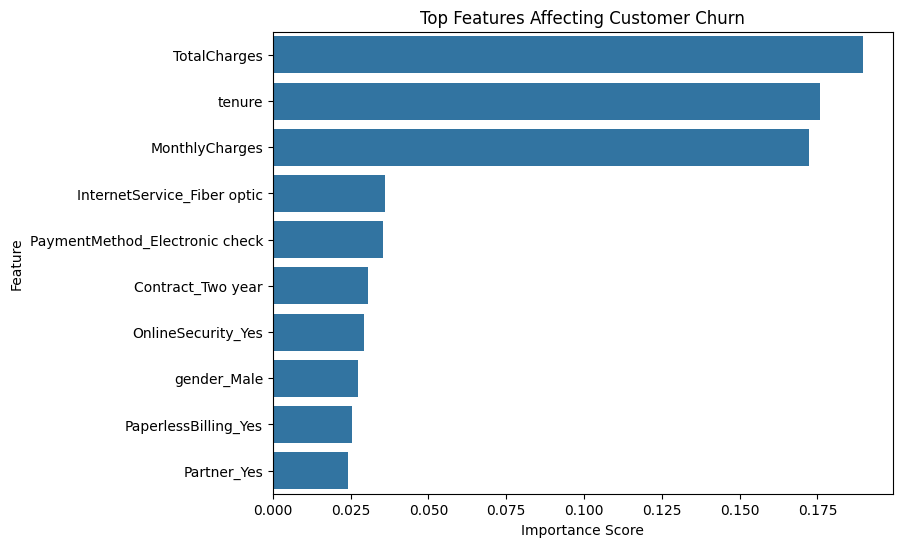

In [27]:
#Feature Importance Analysis

importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Show top 10 features
top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Features Affecting Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [28]:
#Pick Best Model & Save
# Suppose Random Forest is better
joblib.dump(rf_model, "model.pkl")
print("Model saved as model.pkl")


Model saved as model.pkl
